# Riyadh Metro Stations — Exploratory Data Analysis
---
**Project:** Neighborhood DNA — The 15-Minute City Index  
**Layer:** Transit — Metro (Layer 3a of 4)  
**Objective:** Clean and explore 94 metro stations across 6 lines to build the transit proximity foundation for Riyadh's Livability Score.  

**Pipeline:**
1. Load & Initial Profile
2. Feature Selection
3. Data Processing (types, nulls, duplicates, coordinate parsing)
4. Data Analysis (line distribution, station types, spatial patterns)
5. Fix What Analysis Reveals (multi-line stations, coordinate extraction)
6. Export (`Cleaned_Riyadh_Metro.csv`)

## 1 | Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")

# ── Dark Theme ──
plt.rcParams.update({
    'figure.facecolor': '#0a0e27',
    'axes.facecolor': '#0a0e27',
    'axes.edgecolor': '#2a2f4e',
    'axes.labelcolor': '#c4c7d4',
    'text.color': '#c4c7d4',
    'xtick.color': '#8b8fa3',
    'ytick.color': '#8b8fa3',
    'grid.color': '#1a1f3e',
    'grid.alpha': 0.5,
    'font.family': 'sans-serif',
    'font.size': 11,
    'figure.dpi': 120,
    'figure.figsize': (14, 6)
})

GOLD   = '#f0c05a'
CYAN   = '#4fc3f7'
CORAL  = '#ff6b6b'
MINT   = '#66bb6a'
PURPLE = '#ab47bc'
PALETTE = [GOLD, CYAN, CORAL, MINT, PURPLE, '#ff8a65', '#42a5f5', '#ef5350']

pd.set_option('display.max_columns', None)
print('Setup complete.')

Setup complete.


In [2]:
url = 'https://raw.githubusercontent.com/AbdulrahmanB-25/Machine_Learning_Competition/main/DataSets/metro-stations-in-riyadh-by-metro-line-and-station-type.csv'
df_raw = pd.read_csv(url, encoding="utf-8-sig")

print(f"Loaded {len(df_raw):,} metro station records with {df_raw.shape[1]} columns.")
print(f"Columns: {df_raw.columns.tolist()}")
df_raw.head()

Loaded 94 metro station records with 15 columns.
Columns: ['Index', 'Station code', 'Station name', 'اسم المحطة', 'Metro line number', 'Metro line name', 'اسم مسار القطار', 'Station type code', 'Station type', 'نوع المحطة', 'Sequence of the stops', 'Comments', 'التعليقات', 'Geographical coordinates', 'geo_point_2d']


,Index,Station code,Station name,اسم المحطة,Metro line number,Metro line name,اسم مسار القطار,Station type code,Station type,نوع المحطة,Sequence of the stops,Comments,التعليقات,Geographical coordinates,geo_point_2d
0,40,S02,Dr Sulaiman Al Habib,د.سليمان الحبيب,Line1,Blue line,المسار الأزرق,1,Elevated,مرتفع,2,NaN,NaN,"{""coordinates"": [46.62654386725997, 24.8115537...","24.81155379383345, 46.62654386725997"
1,49,S03,KAFD,المركز المالي,Line1,Blue line,المسار الأزرق,1,Elevated,مرتفع,3,NaN,NaN,"{""coordinates"": [46.64364447641301, 24.7680039...","24.76800392512061, 46.64364447641301"
2,18,S04,Al Murooj,المروج,Line1,Blue line,المسار الأزرق,4,Deep Underground,تحت الأرض على عمق كبير,4,NaN,NaN,"{""coordinates"": [46.65422135694412, 24.7547460...","24.75474607607529, 46.65422135694412"
3,56,S05,King Fahad District,حي الملك فهد,Line1,Blue line,المسار الأزرق,4,Deep Underground,تحت الأرض على عمق كبير,5,NaN,NaN,"{""coordinates"": [46.65932671648558, 24.7449144...","24.74491442205136, 46.65932671648558"
4,24,S08,Al Wurud 2,الورود 2,Line1,Blue line,المسار الأزرق,4,Deep Underground,تحت الأرض على عمق كبير,8,NaN,NaN,"{""coordinates"": [46.67112888545265, 24.7217274...","24.72172740595173, 46.67112888545265"


## 2 | Initial Data Profile
First look at the raw 15-column dataset before any cleaning.

In [3]:
print("=" * 60)
print("DATA TYPES & MISSING VALUES")
print("=" * 60)
info_df = pd.DataFrame({
    'dtype':    df_raw.dtypes,
    'non_null': df_raw.count(),
    'null':     df_raw.isnull().sum(),
    'null_%':   (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
})
print(info_df)
print(f"\nTotal rows: {len(df_raw):,}")

DATA TYPES & MISSING VALUES
                           dtype  non_null  null  null_%
Index                      int64        94     0    0.00
Station code              object        94     0    0.00
Station name              object        94     0    0.00
اسم المحطة                object        94     0    0.00
Metro line number         object        94     0    0.00
Metro line name           object        94     0    0.00
اسم مسار القطار           object        94     0    0.00
Station type code          int64        94     0    0.00
Station type              object        94     0    0.00
نوع المحطة                object        94     0    0.00
Sequence of the stops      int64        94     0    0.00
Comments                  object        10    84   89.36
التعليقات                 object        10    84   89.36
Geographical coordinates  object        94     0    0.00
geo_point_2d              object        94     0    0.00

Total rows: 94


In [4]:
print("=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)
df_raw.describe(include="all")

DESCRIPTIVE STATISTICS


,Index,Station code,Station name,اسم المحطة,Metro line number,Metro line name,اسم مسار القطار,Station type code,Station type,نوع المحطة,Sequence of the stops,Comments,التعليقات,Geographical coordinates,geo_point_2d
count,94.000000,94,94,94,94,94,94,94.000000,94,94,94.000000,10,10,94,94
unique,NaN,83,83,83,6,6,6,NaN,4,4,NaN,10,10,91,91
top,NaN,S03,KAFD,المركز المالي,Line1,Blue line,المسار الأزرق,NaN,Elevated,مرتفع,NaN,"Modification on the 26.03.2025, the English na...",تعديل بتاريخ 26.03.2025، تم تغيير الاسم الإنجل...,"{""coordinates"": [46.64360617754577, 24.7681786...","24.7681786337211, 46.64360617754577"
freq,NaN,3,3,3,25,25,25,NaN,40,40,NaN,1,1,2,2
mean,48.127660,NaN,NaN,NaN,NaN,NaN,NaN,2.510638,NaN,NaN,47.500000,NaN,NaN,NaN,NaN
std,28.202125,NaN,NaN,NaN,NaN,NaN,NaN,1.389242,NaN,NaN,27.279418,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN
25%,24.250000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,24.250000,NaN,NaN,NaN,NaN
50%,47.500000,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,47.500000,NaN,NaN,NaN,NaN
75%,70.750000,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,70.750000,NaN,NaN,NaN,NaN


## 3 | Feature Selection

From 15 raw columns, we keep **5 features** needed for the Transit layer:

### Kept Features:
| Feature | Role |
|---|---|
| `Station name` | Station identity — needed for labeling and deduplication |
| `Metro line name` | Line identity (Blue, Red, Green, Orange, Yellow, Purple) — for network analysis |
| `Station type` | Construction type (Elevated, Underground, At Grade) — affects accessibility |
| `geo_point_2d` | Coordinates — will be parsed into `lat` / `lng` for spatial joining |

### Dropped Features & Rationale:
| Column(s) | Why Dropped |
|---|---|
| `Index` | Row index from original source — no analytical value |
| `Station code` | Internal station ID (S02, S03…) — redundant with station name |
| `اسم المحطة` | Arabic station name — duplicate of `Station name` in Arabic |
| `Metro line number` | Line ID (Line1, Line2…) — redundant with `Metro line name` |
| `اسم مسار القطار` | Arabic line name — duplicate of `Metro line name` in Arabic |
| `Station type code` | Numeric code for station type — redundant with `Station type` text |
| `نوع المحطة` | Arabic station type — duplicate of `Station type` in Arabic |
| `Sequence of the stops` | Stop ordering within a line — not needed for spatial proximity |
| `Comments`, `التعليقات` | 89% null; free-text notes with no structured information |
| `Geographical coordinates` | Raw JSON format — `geo_point_2d` is the cleaner parsed version |

In [5]:
keep_cols = ['Station name', 'Metro line name', 'Station type', 'geo_point_2d']
df = df_raw[keep_cols].copy()

print(f"Selected {len(df.columns)} features from {df_raw.shape[1]} available.")
print(f"Dropped {df_raw.shape[1] - len(df.columns)} columns.")
print(f"Shape: {df.shape}")
df.head()

Selected 4 features from 15 available.
Dropped 11 columns.
Shape: (94, 4)


,Station name,Metro line name,Station type,geo_point_2d
0,Dr Sulaiman Al Habib,Blue line,Elevated,"24.81155379383345, 46.62654386725997"
1,KAFD,Blue line,Elevated,"24.76800392512061, 46.64364447641301"
2,Al Murooj,Blue line,Deep Underground,"24.75474607607529, 46.65422135694412"
3,King Fahad District,Blue line,Deep Underground,"24.74491442205136, 46.65932671648558"
4,Al Wurud 2,Blue line,Deep Underground,"24.72172740595173, 46.67112888545265"


## 4 | Data Processing
Parse coordinates, validate data types, and check for duplicates.

In [6]:
initial_count = len(df)
cleaning_log = []

# Step 1: Parse geo_point_2d into lat/lng
df['lat'] = df['geo_point_2d'].str.split(', ').str[0].astype(float)
df['lng'] = df['geo_point_2d'].str.split(', ').str[1].astype(float)
df = df.drop(columns=['geo_point_2d'])
print(f"Step 1 — Parsed coordinates: lat [{df['lat'].min():.4f} – {df['lat'].max():.4f}], lng [{df['lng'].min():.4f} – {df['lng'].max():.4f}]")

# Step 2: Check for null values
before = len(df)
df = df.dropna()
removed = before - len(df)
cleaning_log.append(('Null values', removed))
print(f"Step 2 — Null values removed: {removed:,}")

# Step 3: Validate coordinates are within Riyadh
before = len(df)
lat_ok = (df['lat'] >= 24.3) & (df['lat'] <= 25.1)
lng_ok = (df['lng'] >= 46.2) & (df['lng'] <= 47.1)
df = df[lat_ok & lng_ok]
removed = before - len(df)
cleaning_log.append(('Outside Riyadh bounds', removed))
print(f"Step 3 — Outside Riyadh bounds removed: {removed:,}")

# Step 4: Remove exact row duplicates
before = len(df)
df = df.drop_duplicates()
removed = before - len(df)
cleaning_log.append(('Exact duplicates', removed))
print(f"Step 4 — Exact duplicates removed: {removed:,}")

df = df.reset_index(drop=True)

total_removed = initial_count - len(df)
print(f'\n{"=" * 60}')
print("CLEANING SUMMARY")
print(f'{"=" * 60}')
print(f"Started with:  {initial_count:,}")
print(f"Removed total: {total_removed:,} ({total_removed/initial_count*100:.2f}%)")
print(f"Final count:   {len(df):,}")

Step 1 — Parsed coordinates: lat [24.5596 – 24.9628], lng [46.5434 – 46.8603]
Step 2 — Null values removed: 0
Step 3 — Outside Riyadh bounds removed: 0
Step 4 — Exact duplicates removed: 0

CLEANING SUMMARY
Started with:  94
Removed total: 0 (0.00%)
Final count:   94


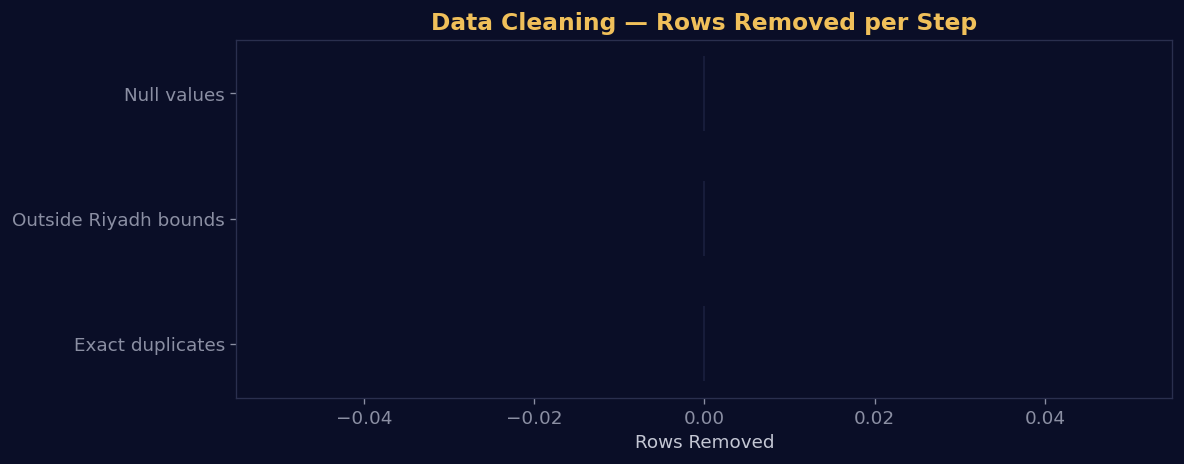

In [7]:
# ── Cleaning Summary Chart ──
fig, ax = plt.subplots(figsize=(10, 4))
steps  = [s[0] for s in cleaning_log]
counts = [s[1] for s in cleaning_log]
colors = [CORAL if c > 0 else "#2a2f4e" for c in counts]

bars = ax.barh(steps, counts, color=colors, edgecolor="#1a1f3e", height=0.6)
for bar, count in zip(bars, counts):
    if count > 0:
        ax.text(bar.get_width() + max(max(counts), 1) * 0.02,
                bar.get_y() + bar.get_height() / 2,
                f'{count:,}', va='center', fontsize=11, color=GOLD, fontweight='bold')

ax.set_xlabel('Rows Removed')
ax.set_title('Data Cleaning — Rows Removed per Step', fontsize=14, fontweight='bold', color=GOLD)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 5 | Data Analysis
Explore the metro network structure, station types, and spatial coverage.

### 5.1 | Stations per Metro Line

Stations per metro line:
  Blue line        25 stations
  Orange line      22 stations
  Red line         15 stations
  Green line       12 stations
  Purple line      11 stations
  Yellow line       9 stations

Total: 94 station-entries (83 unique stations)


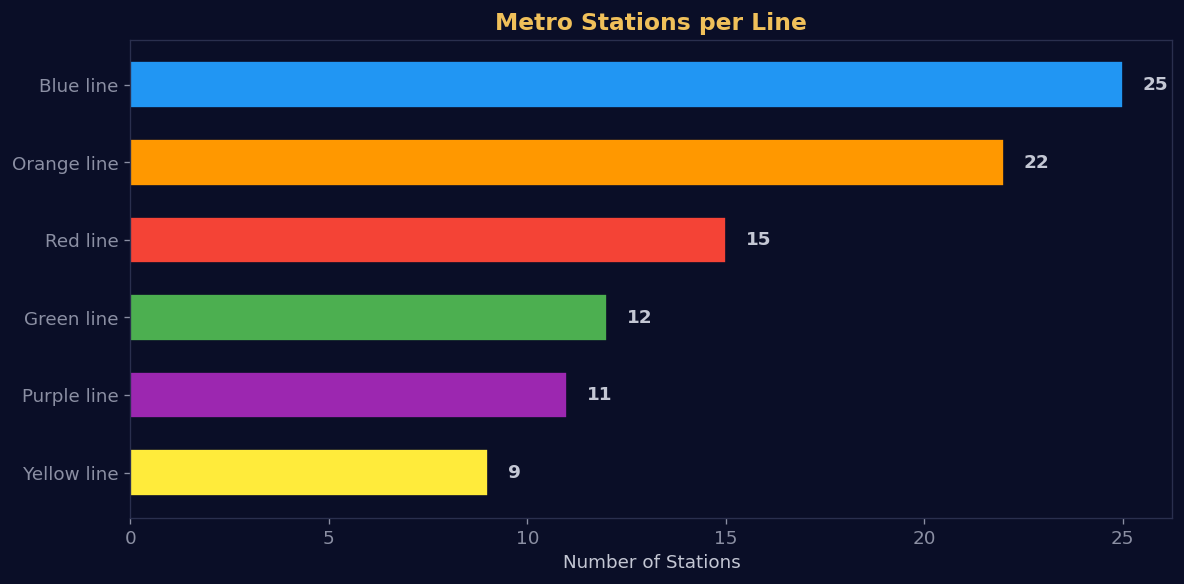

In [8]:
line_counts = df['Metro line name'].value_counts()

print("Stations per metro line:")
for name, count in line_counts.items():
    print(f"  {name:<15} {count:>3} stations")
print(f"\nTotal: {len(df)} station-entries ({df["Station name"].nunique()} unique stations)")

# Color map matching actual Riyadh Metro line colors
line_colors = {'Blue line': '#2196F3', 'Orange line': '#FF9800', 'Red line': '#F44336',
               'Green line': '#4CAF50', 'Purple line': '#9C27B0', 'Yellow line': '#FFEB3B'}

fig, ax = plt.subplots(figsize=(10, 5))
colors = [line_colors.get(name, GOLD) for name in line_counts.index]
bars = ax.barh(range(len(line_counts)), line_counts.values, color=colors,
               edgecolor="#0a0e27", height=0.6)
ax.set_yticks(range(len(line_counts)))
ax.set_yticklabels(line_counts.index, fontsize=11)
ax.invert_yaxis()

for bar, val in zip(bars, line_counts.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val}', va='center', fontsize=11, color='#c4c7d4', fontweight='bold')

ax.set_xlabel('Number of Stations')
ax.set_title('Metro Stations per Line', fontsize=14, fontweight='bold', color=GOLD)
plt.tight_layout()
plt.show()

### 5.2 | Station Type Distribution

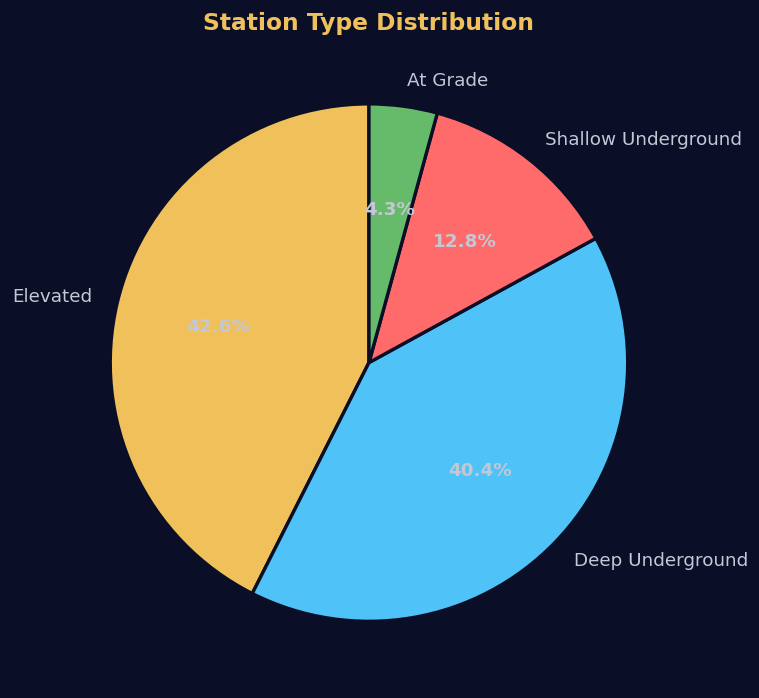

  Elevated                   40 (42.6%)
  Deep Underground           38 (40.4%)
  Shallow Underground        12 (12.8%)
  At Grade                    4 (4.3%)


In [9]:
type_counts = df['Station type'].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    type_counts.values, labels=type_counts.index,
    colors=PALETTE[:len(type_counts)], autopct='%1.1f%%',
    textprops={'color': '#c4c7d4', 'fontsize': 11},
    wedgeprops={'edgecolor': '#0a0e27', 'linewidth': 2},
    startangle=90
)
for t in autotexts:
    t.set_fontweight('bold')
ax.set_title('Station Type Distribution', fontsize=14, fontweight='bold', color=GOLD)
plt.show()

for name, count in type_counts.items():
    print(f"  {name:<25} {count:>3} ({count/len(df)*100:.1f}%)")

### 5.3 | Station Type by Line

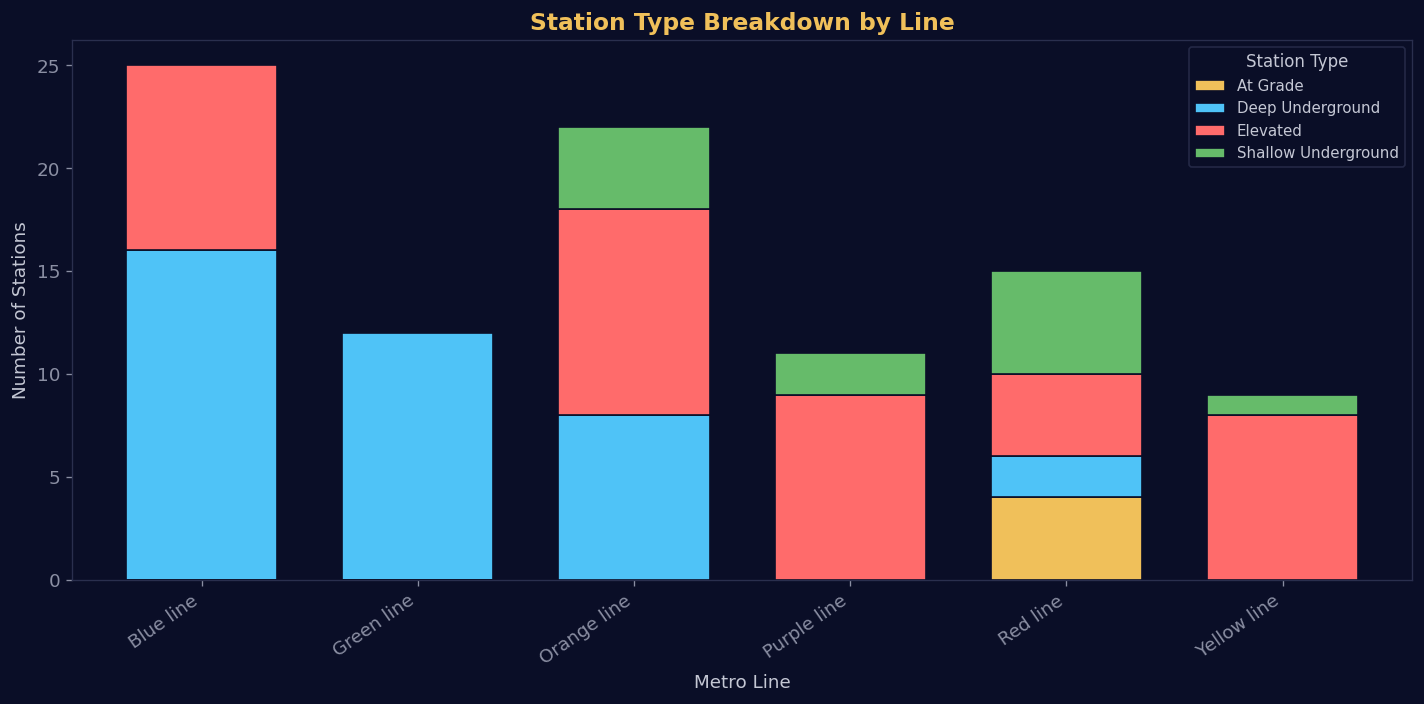

In [10]:
ct = pd.crosstab(df['Metro line name'], df['Station type'])

fig, ax = plt.subplots(figsize=(12, 6))
ct.plot(kind="bar", stacked=True, ax=ax, color=PALETTE[:len(ct.columns)],
        edgecolor="#0a0e27", width=0.7)
ax.set_xlabel('Metro Line')
ax.set_ylabel('Number of Stations')
ax.set_title('Station Type Breakdown by Line', fontsize=14, fontweight='bold', color=GOLD)
ax.legend(title="Station Type", facecolor="#0a0e27", edgecolor="#2a2f4e",
          title_fontsize=10, fontsize=9)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

### 5.4 | Spatial Distribution
Mapping all metro stations across Riyadh, colored by line.

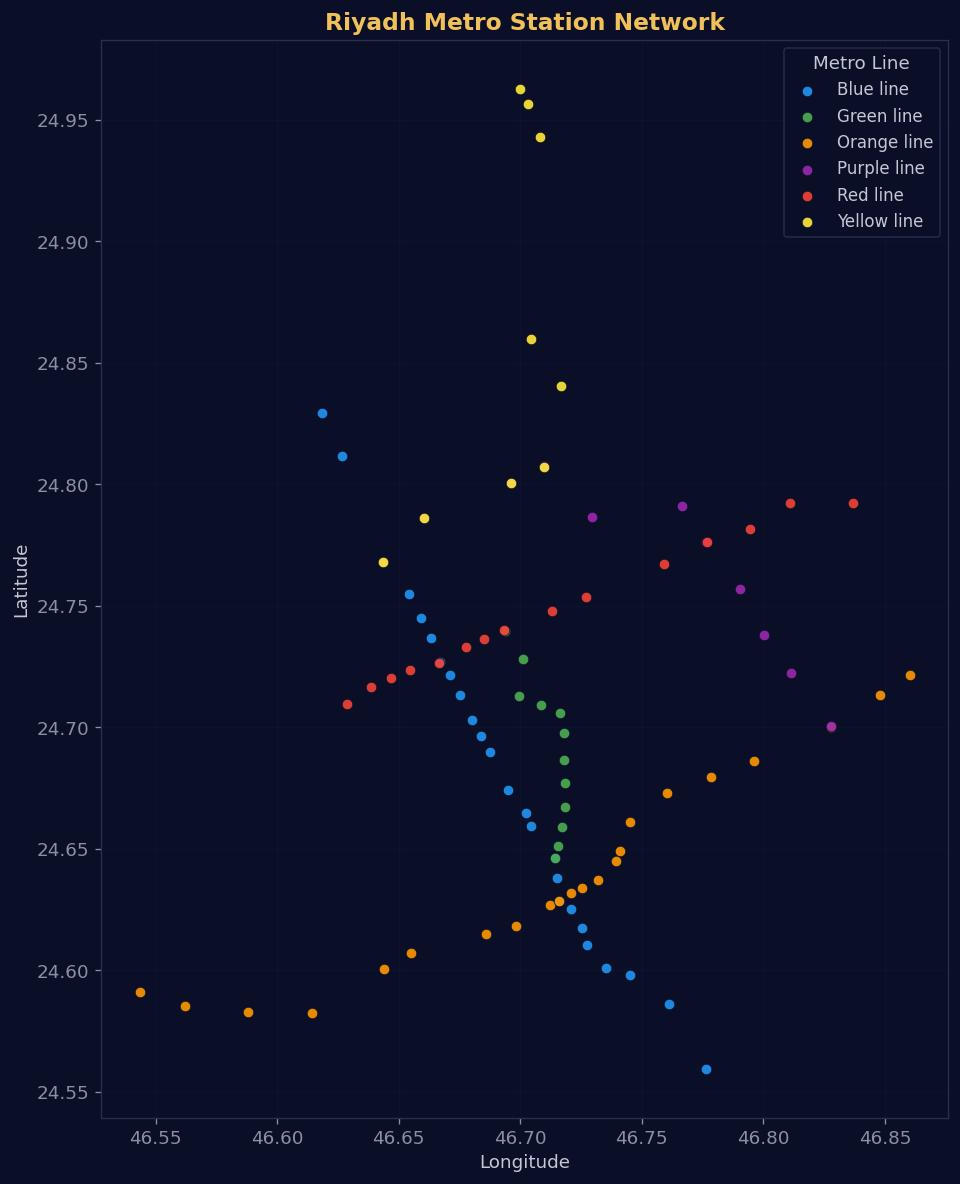

In [11]:
fig, ax = plt.subplots(figsize=(10, 10))

for line_name, group in df.groupby('Metro line name'):
    color = line_colors.get(line_name, GOLD)
    ax.scatter(group['lng'], group['lat'], c=color, s=40, alpha=0.9,
               edgecolors='#0a0e27', linewidth=0.5, label=line_name, zorder=3)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Riyadh Metro Station Network', fontsize=14, fontweight='bold', color=GOLD)
ax.set_aspect('equal')
ax.legend(facecolor="#0a0e27", edgecolor="#2a2f4e", fontsize=10, title="Metro Line",
          title_fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.5 | Multi-Line Interchange Stations
Stations where multiple metro lines intersect — these are major transit hubs.

In [12]:
# Find stations appearing on multiple lines
station_lines = df.groupby('Station name')['Metro line name'].apply(list).reset_index()
station_lines['n_lines'] = station_lines['Metro line name'].apply(len)
interchanges = station_lines[station_lines['n_lines'] > 1].sort_values('n_lines', ascending=False)

print(f"Interchange stations (multi-line): {len(interchanges)}")
print(f"Single-line stations: {len(station_lines) - len(interchanges)}")
print(f"\nInterchange details:")
for _, row in interchanges.iterrows():
    lines = ", ".join(row["Metro line name"])
    print(f"  {row["Station name"]:<30} → {lines}")

Interchange stations (multi-line): 10
Single-line stations: 73

Interchange details:
  KAFD                           → Blue line, Yellow line, Purple line
  Al Hamra                       → Red line, Purple line
  An Naseem                      → Orange line, Purple line
  Ar Rabi                        → Purple line, Yellow line
  Ministry of Education          → Green line, Red line
  National Museum                → Green line, Blue line
  Qasr Al Hokm                   → Blue line, Orange line
  SABIC                          → Purple line, Yellow line
  Uthman Bin Affan Road          → Purple line, Yellow line
  stc                            → Red line, Blue line


## 6 | Fix What Analysis Reveals
The analysis shows 10 interchange stations appearing as multiple rows (one per line). For the spatial proximity layer, we need **one row per physical station** with all lines listed. We deduplicate by station name, keeping the first coordinate and aggregating line names.

In [13]:
# Deduplicate: one row per physical station
before_dedup = len(df)

df_stations = df.groupby("Station name", as_index=False).agg({
    'Metro line name': lambda x: ' | '.join(sorted(set(x))),
    'Station type': 'first',
    'lat': 'first',
    'lng': 'first'
})

print(f"Before dedup: {before_dedup} rows (station × line entries)")
print(f"After dedup:  {len(df_stations)} rows (unique physical stations)")
print(f"Removed:      {before_dedup - len(df_stations)} duplicate entries")

Before dedup: 94 rows (station × line entries)
After dedup:  83 rows (unique physical stations)
Removed:      11 duplicate entries


## 7 | Export Clean Dataset
Final metro station dataset ready for transit proximity calculations.

In [14]:
output_file = 'Cleaned_Riyadh_Metro.csv'
df_stations.to_csv(output_file, index=False, encoding="utf-8-sig")

print(f"Exported: '{output_file}'")
print(f"   Stations: {len(df_stations)}")
print(f"   Columns:  {list(df_stations.columns)}")
print(f"   Size:     {os.path.getsize(output_file) / 1024:.1f} KB")

try:
    from google.colab import files
    files.download(output_file)
except ImportError:
    print("   (Not in Colab — file saved locally)")

Exported: 'Cleaned_Riyadh_Metro.csv'
   Stations: 83
   Columns:  ['Station name', 'Metro line name', 'Station type', 'lat', 'lng']
   Size:     6.2 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8 | Key Findings & Next Steps

### What We Learned:
1. **Network Size**: Riyadh's metro has 83 unique physical stations across 6 color-coded lines, with Blue and Orange being the longest.
2. **Station Types**: Roughly split between Elevated (43%) and Deep Underground (40%), with a few Shallow Underground and At Grade stations.
3. **Interchange Hubs**: 10 stations serve as interchanges between 2–3 lines (KAFD being the largest with 3 lines). These are high-value transit nodes.
4. **Spatial Coverage**: Stations form clear corridor patterns — mostly along major north-south and east-west arterials, with central Riyadh having the densest coverage.

### Next Steps:
- Combine with bus station data for complete transit coverage.
- Calculate transit proximity scores per neighborhood (distance to nearest station).
- Feed into the composite Livability Score model.